# Algoritmo DSP

En este notebook se encuentra el algoritmo original DSP aplicado sobre una red neuronal recurrente entrenada con la función de redondeo. Está todo el código disponible para modificar exclusivamente los hiperparámetros del modelo y el dataset que se quiere utilizar.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tqdm import tqdm
from graphviz import Digraph

from sklearn.decomposition import PCA

2025-08-27 13:39:20.755598: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-27 13:39:21.457475: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Funciones auxiliares

In [2]:
# Función utilizada para preparar el dataset a un batch size con un seq_len determinado.
# Esta función se encarga de preparar el dataset de forma correcta para poder entrenar
# una red stateful por batches

def transform_many_to_many(input_file, output_file, batch_size, seq_len):
    input_raw = open(input_file, 'r').read()
    output_raw = open(output_file, 'r').read()
    
    symbol2id = {}
    id2symbol = {}
    for i, symbol in enumerate(["a", "b", "$"]):
        symbol2id[symbol] = i
        id2symbol[i] = symbol
    
    inputs_raw = []
    outputs_raw = []
    window_size = len(input_raw)//batch_size
    min_len = window_size+1
    for i in range(batch_size):
        string = input_raw[i*window_size:(i+1)*window_size]        
        output = output_raw[i*window_size:(i+1)*window_size]
        output = output[string.find("$"):]
        string = string[string.find("$"):]
        if len(string) < min_len:
            min_len = len(string)
        inputs_raw.append(string)
        outputs_raw.append(output)
        
    dataset_x_temp = np.zeros((batch_size, min_len))
    dataset_y_temp = np.zeros((batch_size, min_len))
    for i in range(batch_size):
        x = [symbol2id[s] for s in inputs_raw[i][:min_len]]
        y = [int(s) for s in outputs_raw[i][:min_len]]
        dataset_x_temp[i] = x
        dataset_y_temp[i] = y
    
    # Aqui, todas las cadenas empiezan por $ y todas tienen la misma longitud
    # OK
    # Ahora, es necesario recolocar las cadenas por lotes para stateful=True
    num_ventanas = min_len//seq_len
    dataset_x = np.zeros((batch_size*num_ventanas, seq_len))
    dataset_y = np.zeros((batch_size*num_ventanas, seq_len))
    for i in range(num_ventanas):
        lote_x = dataset_x_temp[:, i*seq_len:(i+1)*seq_len]
        lote_y = dataset_y_temp[:, i*seq_len:(i+1)*seq_len]
        dataset_x[i*batch_size:(i+1)*batch_size] = lote_x
        dataset_y[i*batch_size:(i+1)*batch_size] = lote_y
    return dataset_x[:, :, None] == np.arange(3)[None, None, :], dataset_y

In [3]:
# Función utilizada para preparar el dataset a un batch size = 1 con un seq_len determinado.
# Esta función hace lo mismo que la anterior pero asumiendo que el batch_size = 1 para poder
# evaluar después del entrenamiento

def transform_many_to_many_1b(input_file, output_file, batch_size):
    input_raw = open(input_file, 'r').read()
    output_raw = open(output_file, 'r').read()
    
    symbol2id = {}
    id2symbol = {}
    for i, symbol in enumerate(["a", "b", "$"]):
        symbol2id[symbol] = i
        id2symbol[i] = symbol
    
    inputs_raw = []
    outputs_raw = []
    window_size = len(input_raw)//batch_size
    min_len = window_size+1
    for i in range(batch_size):
        string = input_raw[i*window_size:(i+1)*window_size]        
        output = output_raw[i*window_size:(i+1)*window_size]
        output = output[string.find("$"):]
        string = string[string.find("$"):]
        if len(string) < min_len:
            min_len = len(string)
        inputs_raw.append(string)
        outputs_raw.append(output)
        
    dataset_x_temp = np.zeros((batch_size, min_len))
    dataset_y_temp = np.zeros((batch_size, min_len))
    for i in range(batch_size):
        x = [symbol2id[s] for s in inputs_raw[i][:min_len]]
        y = [int(s) for s in outputs_raw[i][:min_len]]
        dataset_x_temp[i] = x
        dataset_y_temp[i] = y
        
    return dataset_x_temp[:, :, None] == np.arange(3)[None, None, :], dataset_y_temp

In [4]:
# Esta función dibuja el autómata a partir de un conjunto de estados, transiciones, estados
# de aceptación y el estado inicial

def crear_diagrama_de_estados(estados, transiciones, aceptacion, estado_inicial, draw_dollar=True):
    # Crear un objeto Digraph
    fsm = Digraph(format='png')
    
    # Configurar orientación hacia la derecha
    fsm.attr(rankdir='LR')
    
    fsm.node("", shape="none", label="")  # Nodo invisible para la flecha inicial
    fsm.edge("", str(estado_inicial))  # Flecha hacia el estado inicial

    # Añadir los estados (nodos)
    for estado in estados:
        if str(estado) == "-2":
            continue
        if estado in aceptacion:
            if True in aceptacion[estado] and False in aceptacion[estado]:
                if aceptacion[estado][True] > aceptacion[estado][False]:
                    fsm.node(str(estado), shape="doublecircle")
                else:
                    fsm.node(str(estado))
            elif True in aceptacion[estado]:
                fsm.node(str(estado), shape="doublecircle")
            else:
                fsm.node(str(estado))
        else:
            fsm.node(str(estado))

    # Añadir las transiciones (aristas)
    for origen in transiciones:
        if str(origen) == "-2":
            continue
        for simbolo in transiciones[origen]:
            if not draw_dollar and simbolo == "$":
                continue
            for destino in transiciones[origen][simbolo]:
                if str(destino) == "-2":
                    continue
                fsm.edge(str(origen), str(destino), label=simbolo)

    # Mostrar el grafo
    return fsm

In [5]:
# Este bloque de código tiene las funciones necesarias para pasar a determinista y minimizar un autómata

def _join_states(states, estado_aceptacion):
        state_names = [str(s) for s in states] # Copia
        state_names.sort()
        new_name = "+".join(state_names)
        return new_name, any(True in estado_aceptacion[s] for s in states)
    
def _process_symbol(current_states, symbol, tabla_transiciones):
    new_current_states = []
    for state in current_states:
        if state in tabla_transiciones:
            if symbol in tabla_transiciones[state]:
                for end_state in tabla_transiciones[state][symbol]:
                    new_current_states.append(end_state)
    return list(set(new_current_states))

def to_deterministic(tabla_transiciones, estado_aceptacion, initial_state=-1):
    """
        Esta función construye un Autómata Finito Determinista a partir del
          automata original.

        Args: No args

        Return:
            Un autómata finito determinista
    """
    # Initial state
    dfa_initial_state = str(initial_state)
    dfa_states = {dfa_initial_state}
    dfa_symbols = ["a", "b", "$"]
    dfa_transitions = {}
    dfa_estado_aceptacion = {dfa_initial_state: {True in estado_aceptacion[initial_state]: 1.0}}

    q = []
    q.append((dfa_initial_state, [initial_state]))
    while q:
        joint_state, current_states = q[0]
        q = q[1:]
        for s in dfa_symbols:
            current_states = current_states
            new_current_states = _process_symbol(current_states, s, tabla_transiciones)

            new_joint_state, new_aceptacion = _join_states(new_current_states, estado_aceptacion)
            if not new_joint_state in dfa_states:
                dfa_states.add(new_joint_state)
                dfa_estado_aceptacion[new_joint_state] = {new_aceptacion: 1.0}
                q.append((new_joint_state, new_current_states))

            if joint_state in dfa_transitions:
                if s in dfa_transitions:
                    dfa_transitions[joint_state][s][new_joint_state] = 1.0
                else:
                    dfa_transitions[joint_state][s] = {new_joint_state: 1.0}
            else:
                dfa_transitions[joint_state] = {s: {new_joint_state: 1.0}}
                
            

    return dfa_initial_state, dfa_states, dfa_transitions, dfa_estado_aceptacion

def _get_reachable_states(tabla_transiciones, estado_ini):
    pending = []
    pending.append(estado_ini)
    reachable_states = []

    while pending:
        state = pending[0]
        pending = pending[1:]
        if state not in reachable_states:
            reachable_states.append(state)
            for symbol in tabla_transiciones[state]:
                end_state = list(tabla_transiciones[state][symbol].keys())[0]
                pending.append(end_state)
    return reachable_states

def _assign_eq_classes(old_eq_classes, reachable_states, tabla_transiciones):
    def _state_same_transitions(s1, s2):
        for symbol in ["a", "b", "$"]:
            eq_class1 = []
            eq_class2 = []
            for end_state in tabla_transiciones[s1][symbol]:
                eq_class1.append(old_eq_classes[end_state])
            for end_state in tabla_transiciones[s2][symbol]:
                eq_class2.append(old_eq_classes[end_state])

            if eq_class1 != eq_class2:
                return False
        return True

    current_eq_classes = {s: -1 for s in reachable_states}
    next_eq_class = 0
    states = list(current_eq_classes.keys())
    for i, state in enumerate(states):
        if current_eq_classes[state] == -1:
            current_eq_classes[state] = next_eq_class

            for j in range(i, len(states)):
                if (current_eq_classes[states[j]] == -1 and
                    old_eq_classes[state] == old_eq_classes[states[j]] and
                    _state_same_transitions(state, states[j])):
                        current_eq_classes[states[j]] = next_eq_class
            next_eq_class += 1
    return current_eq_classes, next_eq_class

def minimize(estados, tabla_transiciones, estado_aceptacion, estado_ini):
        """
            Esta función minimiza un Autómata Finito Determinista"

            Args: No args

            Return:
                Un autómata finito determinista mínimo
        """

        reachable_states = _get_reachable_states(tabla_transiciones, estado_ini)
        old_eq_classes = {s: -1 for s in reachable_states}
        current_eq_classes = {}
        for s in reachable_states:
            current_eq_classes[s] = 1 if s in estado_aceptacion and True in estado_aceptacion[s] else 0

        while current_eq_classes != old_eq_classes:
            old_eq_classes = current_eq_classes
            current_eq_classes, n_classes = _assign_eq_classes(old_eq_classes, reachable_states, tabla_transiciones)

        nuevos_estados = []        
        nuevo_estado_aceptacion = {}
        nueva_tabla_transiciones = {}

        for state, value in current_eq_classes.items():
            new_state = str(value)
            new_state_aceptacion = estado_aceptacion[state]
            if new_state not in nuevos_estados:
                nuevos_estados.append(new_state)
                nuevo_estado_aceptacion[new_state] = new_state_aceptacion


        for state_old, value in current_eq_classes.items():
            start_state = nuevos_estados[value]
            for symbol in ["a", "b", "$"]:
                end_state = list(tabla_transiciones[state_old][symbol].keys())[0]

                end_state = nuevos_estados[current_eq_classes[end_state]]
                if start_state in nueva_tabla_transiciones:
                    if symbol not in nueva_tabla_transiciones[start_state]:
                        nueva_tabla_transiciones[start_state][symbol] = {end_state: 1.0}
                else:
                    nueva_tabla_transiciones[start_state] = {symbol: {end_state: 1.0}}

        return nuevos_estados, nueva_tabla_transiciones, nuevo_estado_aceptacion, current_eq_classes[estado_ini], current_eq_classes

In [6]:
def round_tanh(decimals=0):
    @tf.custom_gradient
    def _rounded_tanh(x):
        scale = 10**decimals
        z = tf.tanh(x)
        output = tf.math.round(z * scale) / scale
    
        def backward(dy):
            custom_grad = 1.0 - tf.square(z)
            return dy * custom_grad
        
        return output, backward
    return _rounded_tanh

Text(0.5, 0, 'x')

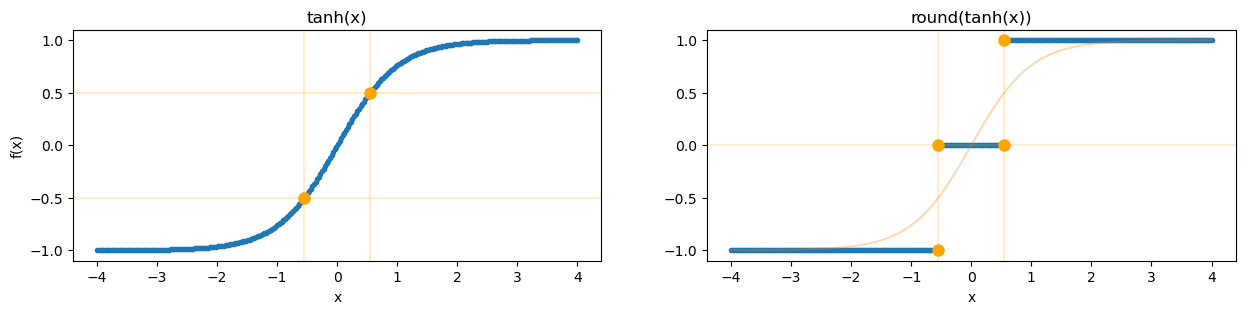

In [9]:
x = np.linspace(-4, 4, 300).astype(np.float32)
y = np.tanh(x)
ry = round_tanh(decimals=0)(x)

plt.figure(figsize=(15, 3))
plt.subplot(1,2,1)
plt.title("tanh(x)")
plt.plot(x, y, '.')
plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot([np.arctanh(-0.5), np.arctanh(0.5)], [-0.5, 0.5], 'o', color="orange", markersize=8)
plt.axhline(-0.5, color="orange", alpha=0.2)
plt.axhline(0.5, color="orange", alpha=0.2)
plt.axvline(np.arctanh(-0.5), color="orange", alpha=0.2)
plt.axvline(np.arctanh(0.5), color="orange", alpha=0.2)
plt.subplot(1,2,2)
plt.title("round(tanh(x))")
plt.plot(x, ry, '.')
plt.plot(x, y, '-', alpha=0.3)
plt.plot([np.arctanh(-0.5), np.arctanh(-0.5), np.arctanh(0.5), np.arctanh(0.5)], [-1.0, 0, 0, 1.0], 'o', color="orange", markersize=8)
plt.axhline(0, color="orange", alpha=0.2)
plt.axvline(np.arctanh(-0.5), color="orange", alpha=0.2)
plt.axvline(np.arctanh(0.5), color="orange", alpha=0.2)
plt.xlabel("x")

In [10]:
# Función de construcción del modelo

def build_model(units, batch_size=1, input_dim=3, l1reg=0.0, optimizer="Adam", use_stateful=True):
    if not use_stateful:
        input_layer = tf.keras.Input(batch_shape=(1, None, input_dim))
        stateful = False
    else:
        input_layer = tf.keras.Input(batch_shape=(batch_size, None, input_dim))
        stateful = True
    rec_layer = tf.keras.layers.SimpleRNN(units, return_sequences=True, 
                                          stateful=stateful,
                                          activation=round_tanh(decimals=0),
                                          kernel_regularizer=tf.keras.regularizers.l1(l1reg),
                                          recurrent_regularizer=tf.keras.regularizers.l1(l1reg),
                                          kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.01),
                                          recurrent_initializer=tf.keras.initializers.RandomNormal(stddev=0.01)
                                         )(input_layer)
    output_layer = tf.keras.layers.Dense(2, activation="softmax",
                                         kernel_regularizer=tf.keras.regularizers.l1(l1reg),
                                         kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.01)
                                        )(rec_layer)
    
    model = tf.keras.Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=optimizer, loss=tf.keras.losses.SparseCategoricalCrossentropy(reduction="sum"), metrics=["accuracy"])
    
    model_rec = tf.keras.Model(inputs=input_layer, outputs=rec_layer)
    return model, model_rec

## Descarga de datos

Se descargan los datos de Github directamente.

In [96]:
seq_len = 25
batch_size = 20

path = "https://raw.githubusercontent.com/christianolivamoya/tesis-contribuciones-xai-dl/refs/heads/main/dataset/tomita/"
problema = "paridad"

input_file = problema + "_train_x.txt"
output_file = problema + "_train_y.txt"
try:
    dataset_x_train, dataset_y_train = transform_many_to_many(input_file, output_file, batch_size, seq_len)
except:
    !wget $path"train/"$input_file
    !wget $path"train/"$output_file
    dataset_x_train, dataset_y_train = transform_many_to_many(input_file, output_file, batch_size, seq_len)
print(dataset_x_train.shape, dataset_y_train.shape)
dataset_x_train_b1, dataset_y_train_b1 = transform_many_to_many_1b(input_file, output_file, 1)
print(dataset_x_train_b1.shape, dataset_y_train_b1.shape)

input_file = problema + "_cadenasLargas_x.txt"
output_file = problema + "_cadenasLargas_y.txt"
try:
    dataset_x_long, dataset_y_long = transform_many_to_many_1b(input_file, output_file, 1)
except:
    !wget $path"test/"$input_file
    !wget $path"test/"$output_file
    dataset_x_long, dataset_y_long = transform_many_to_many_1b(input_file, output_file, 1)
print (dataset_x_long.shape, dataset_y_long.shape)

input_file = problema + "_extremo_muchasA_x.txt"
output_file = problema + "_extremo_muchasA_y.txt"
try:
    dataset_x_allas, dataset_y_allas = transform_many_to_many_1b(input_file, output_file, 1)
except:
    !wget $path"test/"$input_file
    !wget $path"test/"$output_file
    dataset_x_allas, dataset_y_allas = transform_many_to_many_1b(input_file, output_file, 1)
print (dataset_x_allas.shape, dataset_y_allas.shape)

input_file = problema + "_extremo_muchasB_x.txt"
output_file = problema + "_extremo_muchasB_y.txt"
try:
    dataset_x_allbs, dataset_y_allbs = transform_many_to_many_1b(input_file, output_file, 1)
except:
    !wget $path"test/"$input_file
    !wget $path"test/"$output_file
    dataset_x_allbs, dataset_y_allbs = transform_many_to_many_1b(input_file, output_file, 1)
print (dataset_x_allbs.shape, dataset_y_allbs.shape)

input_file = problema + "_testGrande_x.txt"
output_file = problema + "_testGrande_y.txt"
try:
    dataset_x_big, dataset_y_big = transform_many_to_many_1b(input_file, output_file, 1)
except:
    !wget $path"test/"$input_file
    !wget $path"test/"$output_file
    dataset_x_big, dataset_y_big = transform_many_to_many_1b(input_file, output_file, 1)
print (dataset_x_big.shape, dataset_y_big.shape)

(1940, 25, 3) (1940, 25)
(1, 50001, 3) (1, 50001)
(1, 20001, 3) (1, 20001)
(1, 15001, 3) (1, 15001)
(1, 15001, 3) (1, 15001)
(1, 100001, 3) (1, 100001)


## Entrenamiento del modelo

Encontrar un modelo apropiado que tenga las neuronas regularizadas o binarizadas completamente puede ser una tarea tediosa. Sin embargo, el entrenamiento siempre será correcto con un 100% en todos los tests.

In [120]:
with tf.device('/CPU:0'):
    hidden_size=10
    min_epochs=20
    l1reg=0.1
    learning_rate=0.01
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipvalue=5.0)
    model, model_rec = build_model(hidden_size, 
                                   batch_size, 
                                   optimizer=optimizer, 
                                   l1reg=l1reg)
    model_temp, model_rec_temp = build_model(hidden_size, use_stateful=False)
    model.summary()
    
    epoch = 0
    while True:
        if epoch % 10 == 0:
            print(" > Epoch", epoch)
        model.reset_states()
        hist = model.fit(dataset_x_train, dataset_y_train, 
                         shuffle=False, batch_size=batch_size)
        if epoch >= min_epochs:
            model.save_weights("training")
            model_rec.save_weights("training_REC")
            model_temp.load_weights("training")
            model_rec_temp.load_weights("training_REC")
            h = model_temp.evaluate(dataset_x_train_b1, dataset_y_train_b1, batch_size=1, verbose=0)
            if h[1] == 1.0:
                hs = np.concatenate((model_rec_temp.predict(dataset_x_train_b1, batch_size=1, verbose=0)))
                neuronas_activas = ((hs != 0).sum(axis=0) != 0).sum()
                print(" > Num neuronas activas:", neuronas_activas)
                if neuronas_activas <= 4:
                    break
        epoch += 1

Model: "model_62"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_32 (InputLayer)       [(20, None, 3)]           0         
                                                                 
 simple_rnn_31 (SimpleRNN)   (20, None, 10)            140       
                                                                 
 dense_31 (Dense)            (20, None, 2)             22        
                                                                 
Total params: 162 (648.00 Byte)
Trainable params: 162 (648.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
 > Epoch 0
97/97 [==============================] - 0s 3ms/step - loss: 309.5803 - accuracy: 0.6259
 > Epoch 10
97/97 [==============================] - 0s 3ms/step - loss: 4.1830 - accuracy: 1.0000
 > Epoch 20
97/97 [==============================] - 0s 3ms/step - loss: 80.5425 - ac

In [121]:
model.save_weights("training")
model_rec.save_weights("training_REC")
model, model_rec = build_model(hidden_size, use_stateful=False)
model.load_weights("training")
model_rec.load_weights("training_REC")
model.summary()

Model: "model_66"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_34 (InputLayer)       [(1, None, 3)]            0         
                                                                 
 simple_rnn_33 (SimpleRNN)   (1, None, 10)             140       
                                                                 
 dense_33 (Dense)            (1, None, 2)              22        
                                                                 
Total params: 162 (648.00 Byte)
Trainable params: 162 (648.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Evaluación del modelo

In [122]:
print(" > Train dataset:")
model.evaluate(dataset_x_train_b1, dataset_y_train_b1, batch_size=1)
print(" > Big dataset:")
model.evaluate(dataset_x_big, dataset_y_big, batch_size=1)
print(" > Long dataset:")
model.evaluate(dataset_x_long, dataset_y_long, batch_size=1)
print(" > All as dataset:")
model.evaluate(dataset_x_allas, dataset_y_allas, batch_size=1)
print(" > All bs dataset:")
model.evaluate(dataset_x_allbs, dataset_y_allbs, batch_size=1)

 > Train dataset:
1/1 [==============================] - 3s 3s/step - loss: 35.1709 - accuracy: 1.0000
 > Big dataset:
1/1 [==============================] - 6s 6s/step - loss: 70.2678 - accuracy: 1.0000
 > Long dataset:
1/1 [==============================] - 1s 1s/step - loss: 14.4846 - accuracy: 1.0000
 > All as dataset:
1/1 [==============================] - 1s 838ms/step - loss: 8.2260 - accuracy: 1.0000
 > All bs dataset:
1/1 [==============================] - 1s 857ms/step - loss: 13.2037 - accuracy: 1.0000


[13.203730583190918, 1.0]

## Análisis y algoritmo DSP

In [123]:
hs = np.concatenate((model_rec.predict(dataset_x_train_b1, batch_size=1)))
ys = np.concatenate((dataset_y_train_b1))
print(hs.shape, ys.shape)

1/1 [==============================] - 3s 3s/step
(50001, 10) (50001,)


In [124]:
pca = PCA(n_components=2)
pca.fit(hs)
hs_2d = pca.transform(hs)

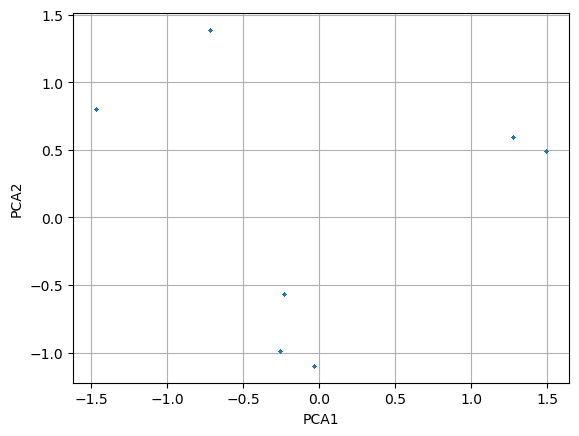

In [125]:
plt.grid()
plt.plot(hs_2d[:, 0], hs_2d[:, 1], '.', alpha=0.01, markersize=3)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

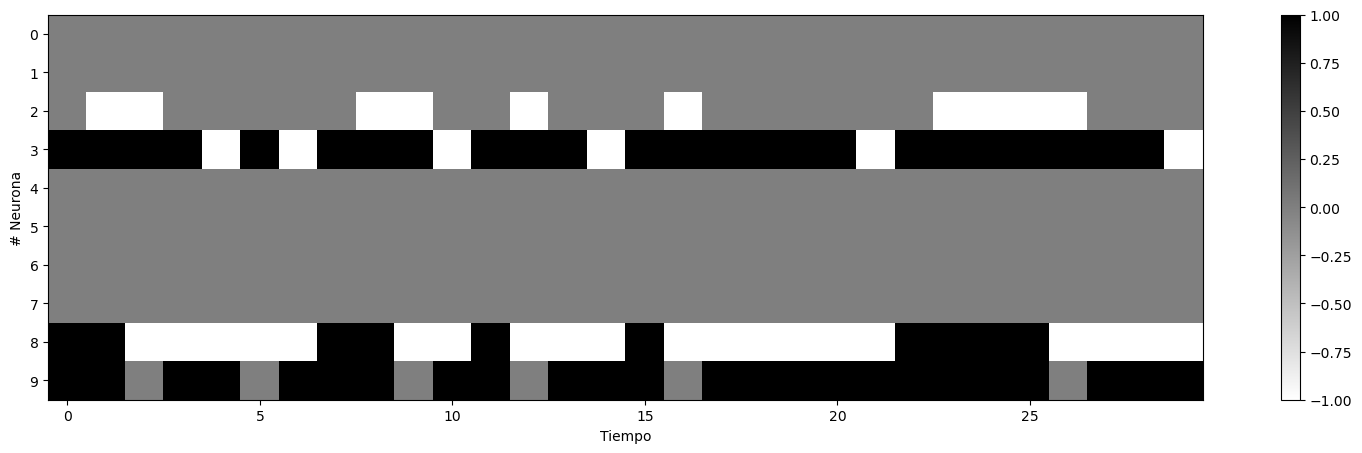

In [126]:
# Visualización de activación de cada neurona oculta
plt.figure(figsize=(20,5))
plt.imshow(hs[:30].T, cmap="binary", vmin=-1, vmax=1)
plt.colorbar()
plt.xlabel("Tiempo")
plt.ylabel("# Neurona")
plt.yticks(range(10), range(10))
plt.show()

In [127]:
Wxh = model.layers[1].weights[0].numpy()
Whh = model.layers[1].weights[1].numpy()
Why = model.layers[2].weights[0].numpy()[:, 1][:, None]
bh = model.layers[1].weights[2].numpy()

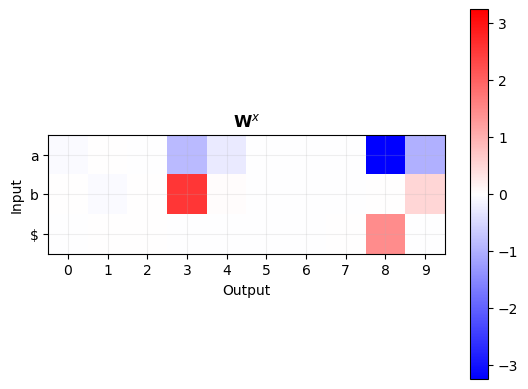

In [128]:
vmax = np.abs(Wxh).max()
vmin = -vmax
plt.imshow(Wxh, vmin=vmin, vmax=vmax, cmap="bwr")
plt.colorbar()
plt.title("$\mathbf{W}^{x}$")
plt.ylabel("Input")
plt.xlabel("Output")
plt.grid(alpha=0.2)
plt.yticks(range(3), ["a", "b", "$"])
plt.xticks(range(10), range(10))
plt.show()

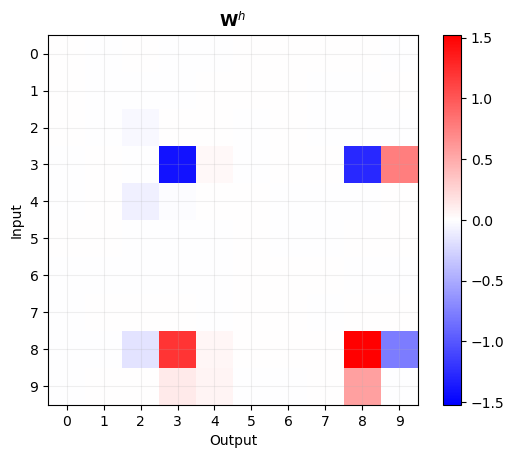

In [129]:
vmax = np.abs(Whh).max()
vmin = -vmax
plt.imshow(Whh, vmin=vmin, vmax=vmax, cmap="bwr")
plt.colorbar()
plt.title("$\mathbf{W}^{h}$")
plt.ylabel("Input")
plt.xlabel("Output")
plt.grid(alpha=0.2)
plt.xticks(range(10), range(10))
plt.yticks(range(10), range(10))
plt.show()

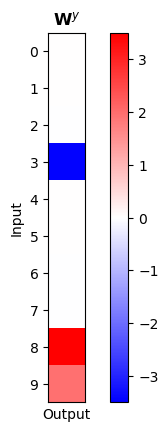

In [130]:
vmax = np.abs(Why).max()
vmin = -vmax
plt.imshow(Why, vmin=vmin, vmax=vmax, cmap="bwr")
plt.colorbar()
plt.title("$\mathbf{W}^{y}$")
plt.ylabel("Input")
plt.xlabel("Output")
plt.xticks([])
plt.yticks(range(10), range(10))
plt.show()

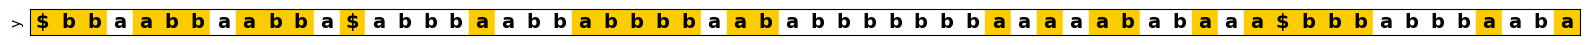

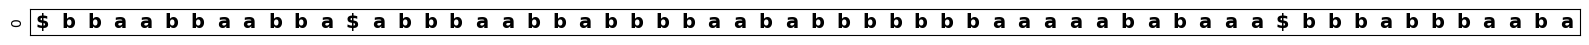

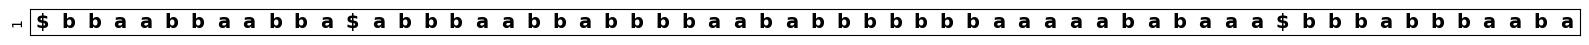

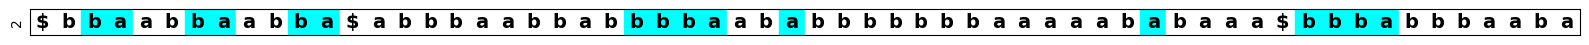

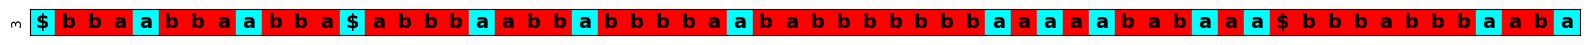

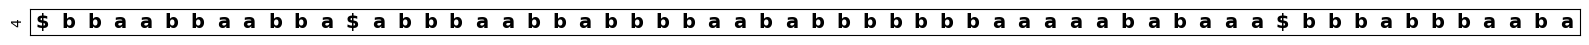

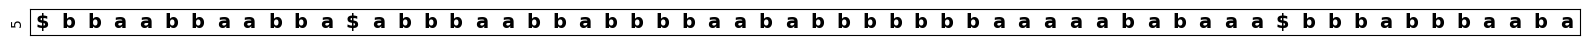

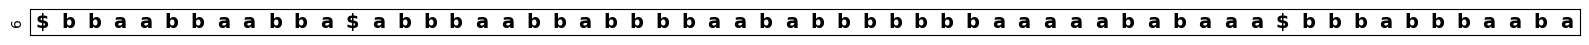

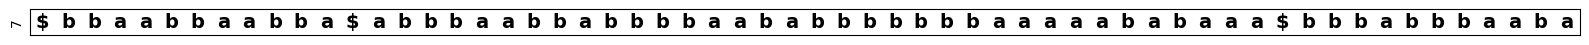

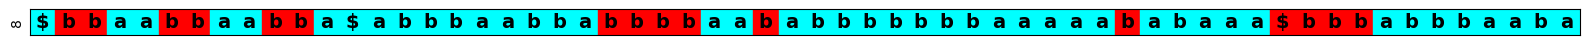

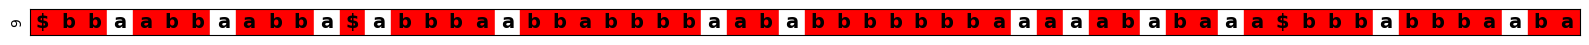

In [143]:
import matplotlib.patches as mpatch

input_file = problema + "_train_x.txt"
text_x = open(input_file, 'r').read()

offset = 49

inputs_print = text_x[offset:offset+60]
probs = dataset_y_train_b1[0, offset:offset+60]
estados = hs[offset:offset+60]

fig, ax = plt.subplots(figsize=(20,20))
plt.ylabel("y")
for i, simbolo in enumerate(inputs_print):
    if probs[i] > 0.5:
        rectangle = mpatch.Rectangle((i,0), 1, 1, color=(1.,0.8,0.))
    else:
        rectangle = mpatch.Rectangle((i,0), 1, 1, color=(1.,1.,1.))

    ax.add_artist(rectangle)
    rx, ry = rectangle.get_xy()
    cx = rx + rectangle.get_width()/2.0
    cy = ry + rectangle.get_height()/2.0

    ax.annotate(simbolo, (cx, cy), color='k', weight='bold', 
                fontsize=14, ha='center', va='center')

ax.set_aspect('equal')
ax.set_xlim((0, 60))
plt.xticks([])
plt.yticks([])
plt.show()

umbral=0.0


for neurona in range(hidden_size):
            fig, ax = plt.subplots(figsize=(20,20))
            plt.ylabel(str(neurona))
            for i, simbolo in enumerate(inputs_print):
                if estados[i][neurona] < 0:
                    rectangle = mpatch.Rectangle((i,0), 1, 1, color=(1.+estados[i][neurona],
                                                                     1.,
                                                                     1.))
                else:
                    rectangle = mpatch.Rectangle((i,0), 1, 1, color=(1.,
                                                                     1.-estados[i][neurona],
                                                                     1.-estados[i][neurona]))

                ax.add_artist(rectangle)
                rx, ry = rectangle.get_xy()
                cx = rx + rectangle.get_width()/2.0
                cy = ry + rectangle.get_height()/2.0

                ax.annotate(simbolo, (cx, cy), color='k', weight='bold', 
                            fontsize=14, ha='center', va='center')

            ax.set_aspect('equal')
            ax.set_xlim((0, 60))
            plt.xticks([])
            plt.yticks([])
            plt.show()

### Paso 1: Clustering del espacio de estados interno

In [144]:
from sklearn.cluster import KMeans
K = 7
km = KMeans(K, n_init="auto")
km.fit(hs)
clusters = km.predict(hs)

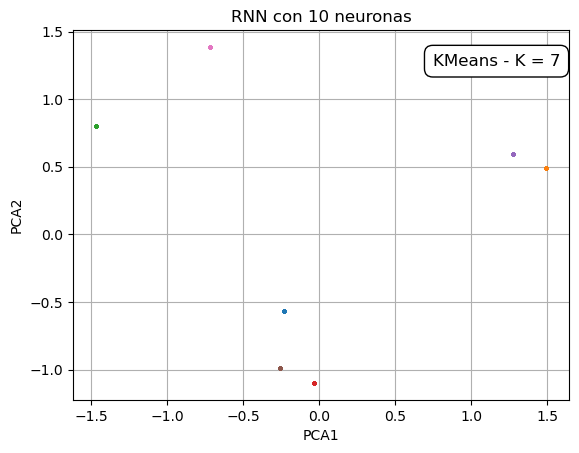

In [145]:
plt.grid()
for c in np.unique(clusters):
    plt.plot(hs_2d[clusters==c, 0], hs_2d[clusters==c, 1], '.', alpha=1, markersize=3)
    
plt.title("RNN con "+str(hidden_size)+" neuronas")
    
plt.text(
    hs_2d[:, 0].max() * (0.4 if K==6 else 0.5),  # Coordenada x
    hs_2d[:, 1].max() * 0.9,  # Coordenada y
    "KMeans - K = "+str(K),  # Texto
    fontsize=12,  # Tamaño de la fuente
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')  # Recuadro
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

### Paso 2: Estracción de la tabla de transiciones

In [146]:
input_file = problema + "_train_x.txt"
text_x = open(input_file, 'r').read()

In [147]:
tabla_transiciones = {}
estado_aceptacion = {}
for i in tqdm(range(len(clusters))):
    simbolo = text_x[i]
    aceptar = ys[i]
    if i == 0:
        estado_ini = -1
    else:
        estado_ini = clusters[i-1]
    estado_aceptar = ys[i]
    estado_fin = clusters[i]
    if estado_fin in estado_aceptacion:
        if estado_aceptar in estado_aceptacion[estado_fin]:
            estado_aceptacion[estado_fin][estado_aceptar == 1] += 1
        else:
            estado_aceptacion[estado_fin][estado_aceptar == 1] = 1
    else:
        estado_aceptacion[estado_fin] = {estado_aceptar == 1: 1}
    if estado_ini in tabla_transiciones:
        if simbolo in tabla_transiciones[estado_ini]:
            if estado_fin in tabla_transiciones[estado_ini][simbolo]:
                tabla_transiciones[estado_ini][simbolo][estado_fin] += 1
            else:
                tabla_transiciones[estado_ini][simbolo][estado_fin] = 1
        else:
            tabla_transiciones[estado_ini][simbolo] = {estado_fin: 1}
    else:
        tabla_transiciones[estado_ini] = {simbolo: {estado_fin: 1}}

100%|█████████████████████████████████| 50001/50001 [00:00<00:00, 344676.41it/s]


In [148]:
# Las transiciones pueden ser no deterministas, luego se gestionan llamando a la función
# to_deterministic

for estado_ini in tabla_transiciones:
    for simbolo in tabla_transiciones[estado_ini]:
        suma = sum(tabla_transiciones[estado_ini][simbolo].values())
        for estado_fin in tabla_transiciones[estado_ini][simbolo]:
            tabla_transiciones[estado_ini][simbolo][estado_fin] /= suma
tabla_transiciones

{-1: {'$': {4: 1.0}},
 4: {'b': {1: 1.0}, 'a': {3: 1.0}, '$': {1: 1.0}},
 1: {'a': {3: 1.0}, '$': {1: 1.0}, 'b': {1: 1.0}},
 3: {'b': {0: 1.0}, 'a': {2: 1.0}, '$': {2: 1.0}},
 0: {'a': {2: 1.0}, 'b': {0: 1.0}, '$': {6: 1.0}},
 2: {'a': {5: 1.0}, 'b': {4: 1.0}, '$': {4: 1.0}},
 5: {'a': {2: 1.0}, 'b': {0: 1.0}, '$': {2: 1.0}},
 6: {'$': {4: 1.0}, 'a': {5: 1.0}, 'b': {4: 1.0}}}

In [149]:
# Si en esta celda salen estados no deterministas en su salida, el autómata resultante
# fallará, ya que no se están considerando estados con salida probabilistica

for estado_ini in estado_aceptacion:
    suma = sum(estado_aceptacion[estado_ini].values())
    for estado_aceptar in estado_aceptacion[estado_ini]:
        estado_aceptacion[estado_ini][estado_aceptar] /= suma
estado_aceptacion

{4: {True: 1.0},
 1: {True: 1.0},
 3: {False: 1.0},
 0: {False: 1.0},
 2: {True: 1.0},
 5: {False: 1.0},
 6: {True: 1.0}}

In [150]:
# Se añade a las transiciones un estado sumidero para simplificar la tabla y tenerla
# completa
tabla_transiciones[-2] = {'$': {-1: 1.0}, "a": {-2: 1.0}, "b": {-2: 1.0}}

for simbolo in ["a", "b", "$"]:
    for estado_ini in tabla_transiciones:
        if simbolo not in tabla_transiciones[estado_ini]:
            tabla_transiciones[estado_ini][simbolo] = {-2: 1.0}
tabla_transiciones

{-1: {'$': {4: 1.0}, 'a': {-2: 1.0}, 'b': {-2: 1.0}},
 4: {'b': {1: 1.0}, 'a': {3: 1.0}, '$': {1: 1.0}},
 1: {'a': {3: 1.0}, '$': {1: 1.0}, 'b': {1: 1.0}},
 3: {'b': {0: 1.0}, 'a': {2: 1.0}, '$': {2: 1.0}},
 0: {'a': {2: 1.0}, 'b': {0: 1.0}, '$': {6: 1.0}},
 2: {'a': {5: 1.0}, 'b': {4: 1.0}, '$': {4: 1.0}},
 5: {'a': {2: 1.0}, 'b': {0: 1.0}, '$': {2: 1.0}},
 6: {'$': {4: 1.0}, 'a': {5: 1.0}, 'b': {4: 1.0}},
 -2: {'$': {-1: 1.0}, 'a': {-2: 1.0}, 'b': {-2: 1.0}}}

In [151]:
for estado in tabla_transiciones:
    if estado not in estado_aceptacion:
        estado_aceptacion[estado] = {False: 1.0}
estado_aceptacion

{4: {True: 1.0},
 1: {True: 1.0},
 3: {False: 1.0},
 0: {False: 1.0},
 2: {True: 1.0},
 5: {False: 1.0},
 6: {True: 1.0},
 -1: {False: 1.0},
 -2: {False: 1.0}}

### Paso 3: Construir el autómata

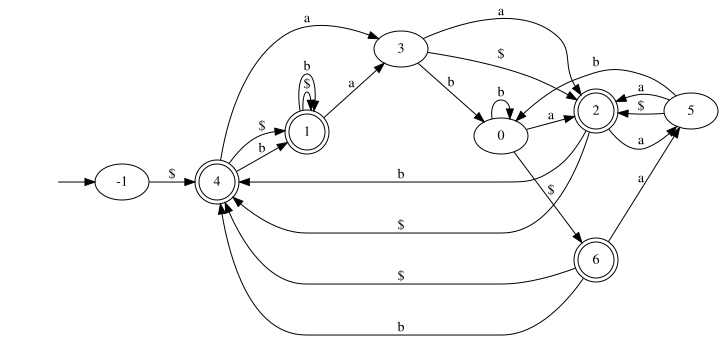

In [152]:
estados = list(tabla_transiciones.keys())
crear_diagrama_de_estados(estados, tabla_transiciones, estado_aceptacion, -1)

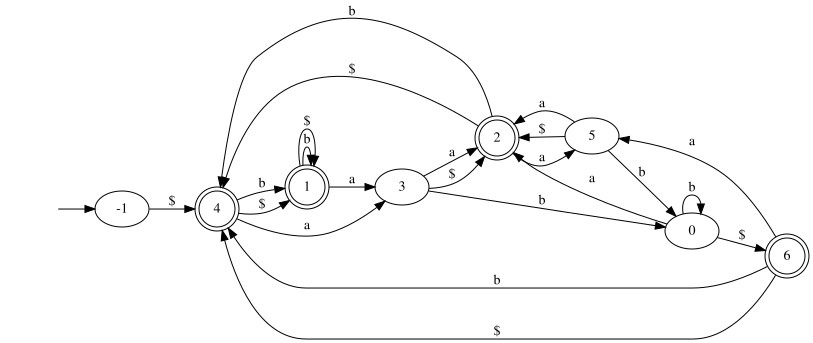

In [153]:
## Pasamos el autómata a determinista
(estado_ini, 
 estados_dfa,
 tabla_transiciones_dfa, 
 estado_aceptacion_dfa) = to_deterministic(tabla_transiciones, estado_aceptacion)

crear_diagrama_de_estados(estados_dfa, tabla_transiciones_dfa, estado_aceptacion_dfa, estado_ini)

### Paso 4: Minimización del autómata

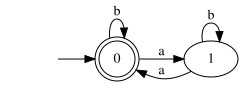

In [154]:
(nuevos_estados, 
 nueva_tabla_transiciones, 
 nuevo_estado_aceptacion, 
 nuevo_estado_ini,
 eq_classes) = minimize(estados_dfa, 
                        tabla_transiciones_dfa, 
                        estado_aceptacion_dfa, 
                        estado_ini=list(tabla_transiciones_dfa[estado_ini]['$'].keys())[0])

crear_diagrama_de_estados(nuevos_estados, 
                          nueva_tabla_transiciones, 
                          nuevo_estado_aceptacion, 
                          estado_inicial=nuevo_estado_ini,
                          draw_dollar=False)